#  IF3270 Machine Learning | Tubes 1

# ~ Kelompok ~
Anggota : 
1. 13523128 Ivant Samuel Silaban
2. 13523133 Rafa Abdussalam Danadyaksa
3. 13523164 Muhammad Rizain Firdaus

# Setup & Import Library

In [76]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path as path

root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from model.layers import FFNN, Linear
from model.activations import Activation
from model.loss import Loss
from model.optimizer import GradientDescent
from model.initializer import Initializer
from utils.data_loader import DataLoader
from utils.visualization import Visualizer

print('Setup selesai!')

Setup selesai!


## Load Data

In [77]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM}')
print(f'Train     : {X_train.shape}')
print(f'Val       : {X_val.shape}')
print(f'Test      : {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim : 21
Train     : (6400, 21)
Val       : (1600, 21)
Test      : (2000, 21)


## FFNN Model

In [78]:
# Hyperparameter
HIDDEN_DIM = [128, 64]
EPOCHS = 500
BATCH_SIZE = 64
LR = 0.01
HIDDEN_ACTIVATION = 'relu'
OUTPUT_ACTIVATION = 'sigmoid'
LOSS_NAME = 'bce'
SEED = 42

In [79]:
model_zero = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'zero',
    seed              = SEED,
)

model_uniform = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'uniform',
    seed              = SEED,
)

model_normal = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'normal',
    seed              = SEED,
)

model_xavier = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'xavier',
    seed              = SEED,
)

model_he = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = HIDDEN_ACTIVATION,
    output_activation = OUTPUT_ACTIVATION,
    loss_name         = LOSS_NAME,
    init_method       = 'he',
    seed              = SEED,
)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: zero, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: uniform, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: normal, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: xavier, seed=42
[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: he, seed=42


# Latih Model

### Model 1: FFNN + Zero Initialization

In [80]:
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

for epoch in range(1, EPOCHS + 1):
    metrics = model_zero.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6874  |  val_loss: 0.6824  |  val_acc: 0.6162
Epoch   2/500  |  train_loss: 0.6790  |  val_loss: 0.6760  |  val_acc: 0.6162
Epoch   3/500  |  train_loss: 0.6739  |  val_loss: 0.6722  |  val_acc: 0.6162
Epoch   4/500  |  train_loss: 0.6708  |  val_loss: 0.6697  |  val_acc: 0.6162
Epoch   5/500  |  train_loss: 0.6689  |  val_loss: 0.6683  |  val_acc: 0.6162
Epoch   6/500  |  train_loss: 0.6677  |  val_loss: 0.6673  |  val_acc: 0.6162
Epoch   7/500  |  train_loss: 0.6670  |  val_loss: 0.6668  |  val_acc: 0.6162
Epoch   8/500  |  train_loss: 0.6665  |  val_loss: 0.6664  |  val_acc: 0.6162
Epoch   9/500  |  train_loss: 0.6663  |  val_loss: 0.6662  |  val_acc: 0.6162
Epoch  10/500  |  train_loss: 0.6661  |  val_loss: 0.6661  |  val_acc: 0.6162
Epoch  11/500  |  train_loss: 0.6660  |  val_loss: 0.6660  |  val_acc: 0.6162
Epoch  12/500  |  train_loss: 0.6659  |  val_loss: 0.6659  |  val_acc: 0.6162
Epoch  13/500  |  train_loss: 0.6659  |  val_loss: 0.6659  |  va

### Visualisasi

### 1. Plot Traning History

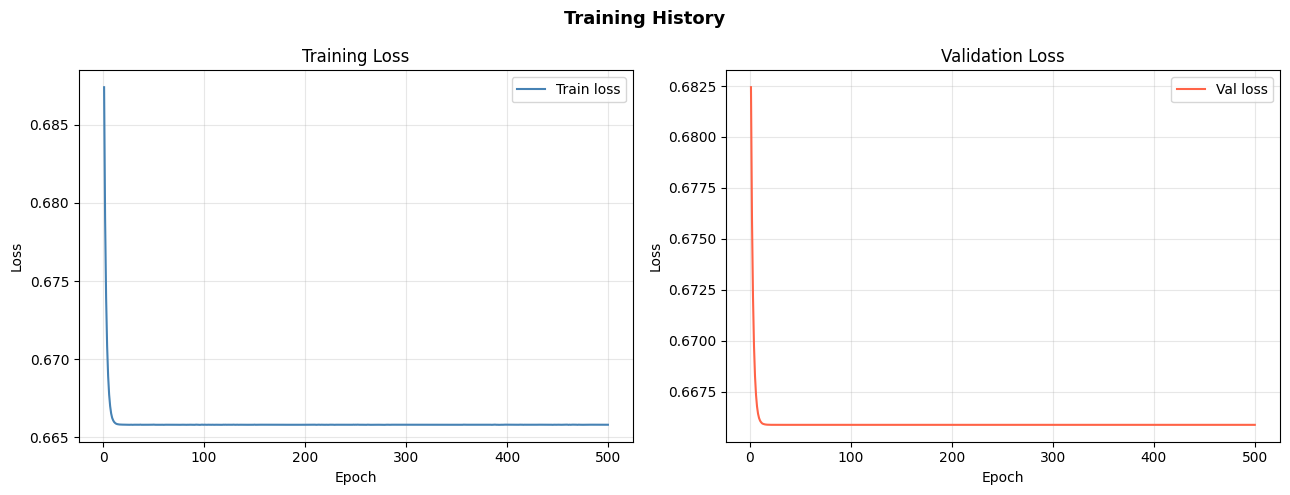

In [81]:
viz = Visualizer()
history = model_zero.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

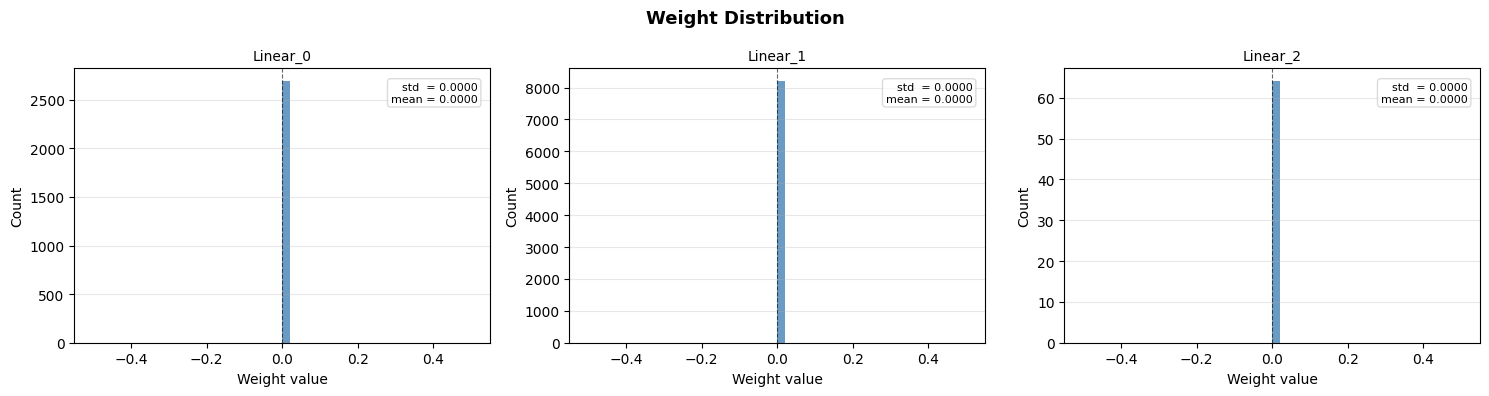

In [82]:
weights = model_zero.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

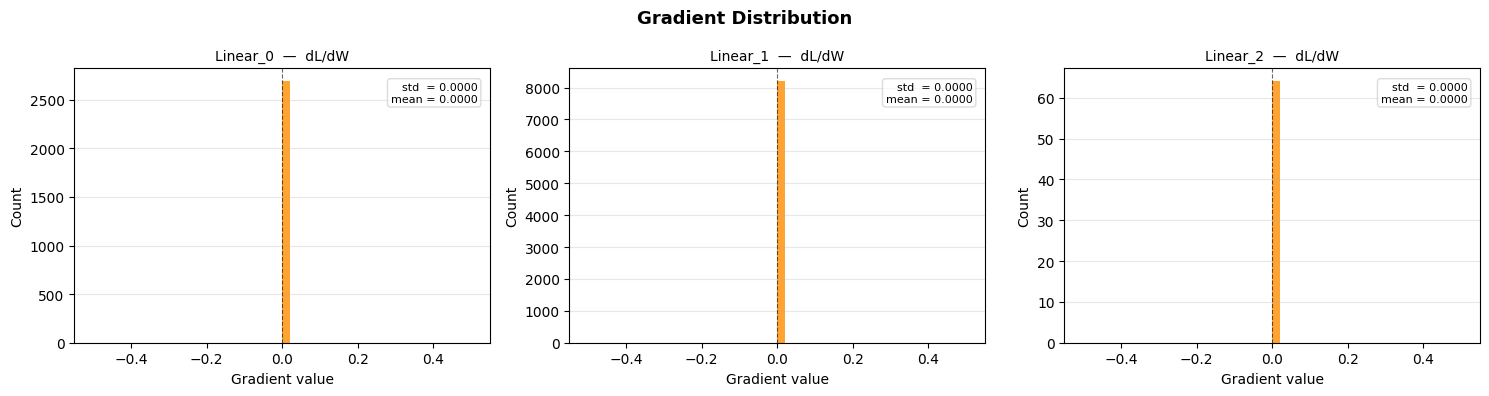

In [83]:
y_pred_viz = model_zero.forward(X_test)
model_zero.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_zero.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [84]:
y_pred  = model_zero.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6110


### Save Model

In [85]:
os.makedirs('../output', exist_ok=True)
model_zero.save('../output/zero_initializer.npz')

[FFNN] Model tersimpan di '../output/zero_initializer.npz' 


### Verifikasi Load Model

## Model 2: FFNN + Random Uniform Initialization

In [86]:
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

for epoch in range(1, EPOCHS + 1):
    metrics = model_uniform.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.7915  |  val_loss: 0.5795  |  val_acc: 0.7163
Epoch   2/500  |  train_loss: 0.5790  |  val_loss: 0.5426  |  val_acc: 0.7444
Epoch   3/500  |  train_loss: 0.5530  |  val_loss: 0.5276  |  val_acc: 0.7500
Epoch   4/500  |  train_loss: 0.5392  |  val_loss: 0.5189  |  val_acc: 0.7538
Epoch   5/500  |  train_loss: 0.5294  |  val_loss: 0.5115  |  val_acc: 0.7606
Epoch   6/500  |  train_loss: 0.5221  |  val_loss: 0.5072  |  val_acc: 0.7631
Epoch   7/500  |  train_loss: 0.5167  |  val_loss: 0.5049  |  val_acc: 0.7562
Epoch   8/500  |  train_loss: 0.5124  |  val_loss: 0.5015  |  val_acc: 0.7625
Epoch   9/500  |  train_loss: 0.5087  |  val_loss: 0.4992  |  val_acc: 0.7625
Epoch  10/500  |  train_loss: 0.5065  |  val_loss: 0.5027  |  val_acc: 0.7562
Epoch  11/500  |  train_loss: 0.5036  |  val_loss: 0.4958  |  val_acc: 0.7631
Epoch  12/500  |  train_loss: 0.5006  |  val_loss: 0.4986  |  val_acc: 0.7656
Epoch  13/500  |  train_loss: 0.4998  |  val_loss: 0.4939  |  va

### Visualisasi

### 1. Plot Traning History

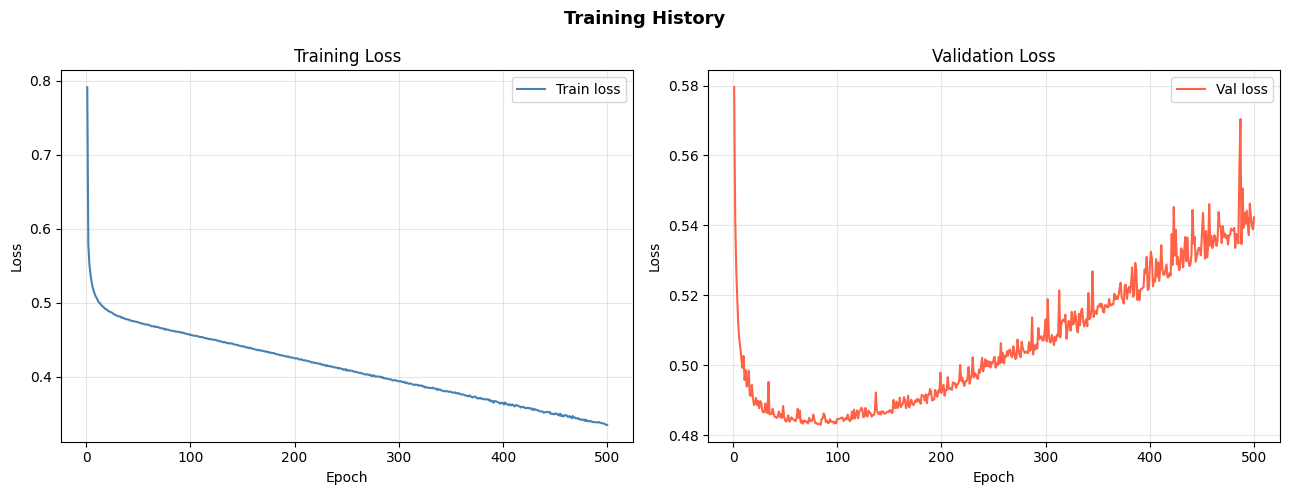

In [87]:
viz = Visualizer()
history = model_uniform.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

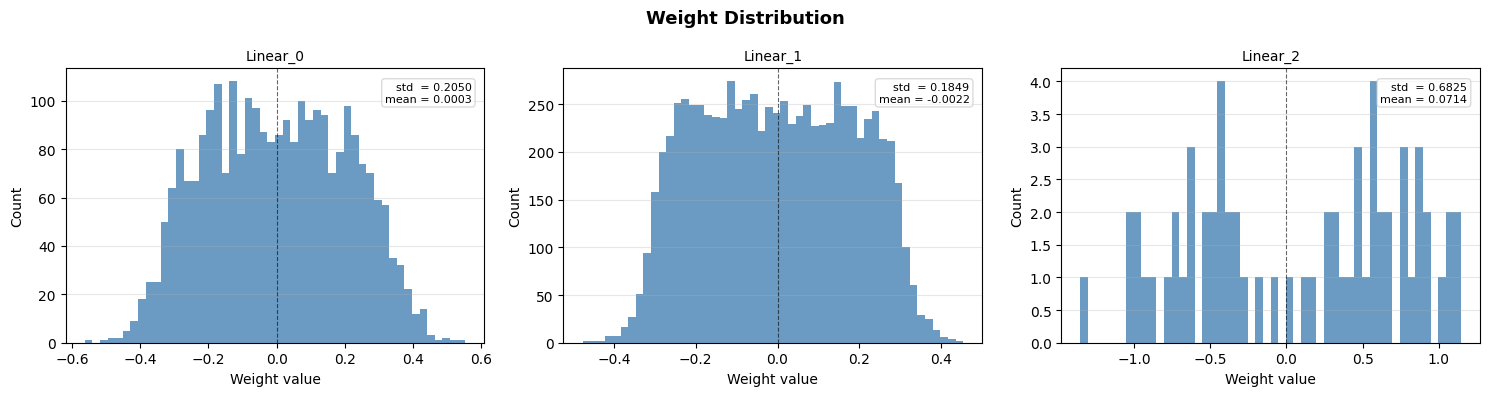

In [88]:
weights = model_uniform.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

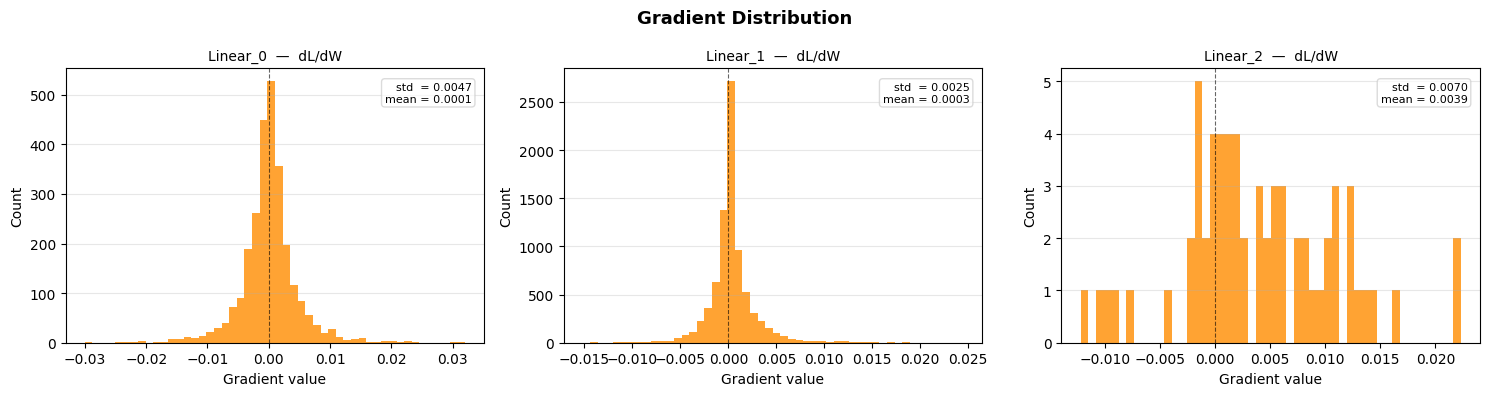

In [89]:
y_pred_viz = model_uniform.forward(X_test)
model_uniform.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_uniform.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [90]:
y_pred  = model_uniform.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7200


### Save Model

In [91]:
os.makedirs('../output', exist_ok=True)
model_uniform.save('../output/uniform_initializer.npz')

[FFNN] Model tersimpan di '../output/uniform_initializer.npz' 


### Verifikasi Load Model

## Model 3: FFNN + Normal Initialization

In [92]:
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

for epoch in range(1, EPOCHS + 1):
    metrics = model_normal.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 10.3340  |  val_loss: 6.8820  |  val_acc: 0.7356
Epoch   2/500  |  train_loss: 6.8267  |  val_loss: 6.0208  |  val_acc: 0.7194
Epoch   3/500  |  train_loss: 5.7893  |  val_loss: 5.5095  |  val_acc: 0.6819
Epoch   4/500  |  train_loss: 5.1386  |  val_loss: 6.1790  |  val_acc: 0.6156
Epoch   5/500  |  train_loss: 4.7032  |  val_loss: 6.6209  |  val_acc: 0.6900
Epoch   6/500  |  train_loss: 3.8975  |  val_loss: 2.7003  |  val_acc: 0.6931
Epoch   7/500  |  train_loss: 3.0025  |  val_loss: 1.7752  |  val_acc: 0.7419
Epoch   8/500  |  train_loss: 2.3919  |  val_loss: 3.7939  |  val_acc: 0.6713
Epoch   9/500  |  train_loss: 1.8291  |  val_loss: 1.9905  |  val_acc: 0.5825
Epoch  10/500  |  train_loss: 1.4894  |  val_loss: 1.4980  |  val_acc: 0.6575
Epoch  11/500  |  train_loss: 1.1609  |  val_loss: 1.0499  |  val_acc: 0.7288
Epoch  12/500  |  train_loss: 1.0718  |  val_loss: 1.0214  |  val_acc: 0.6819
Epoch  13/500  |  train_loss: 0.9253  |  val_loss: 1.0867  |  v

### Visualisasi

### 1. Plot Traning History

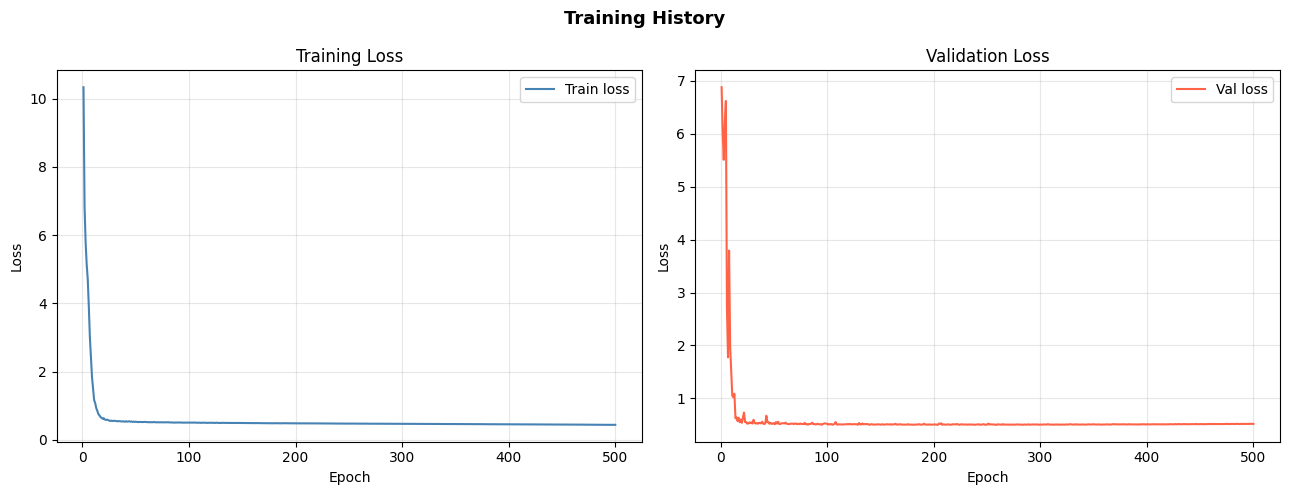

In [93]:
viz = Visualizer()
history = model_normal.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

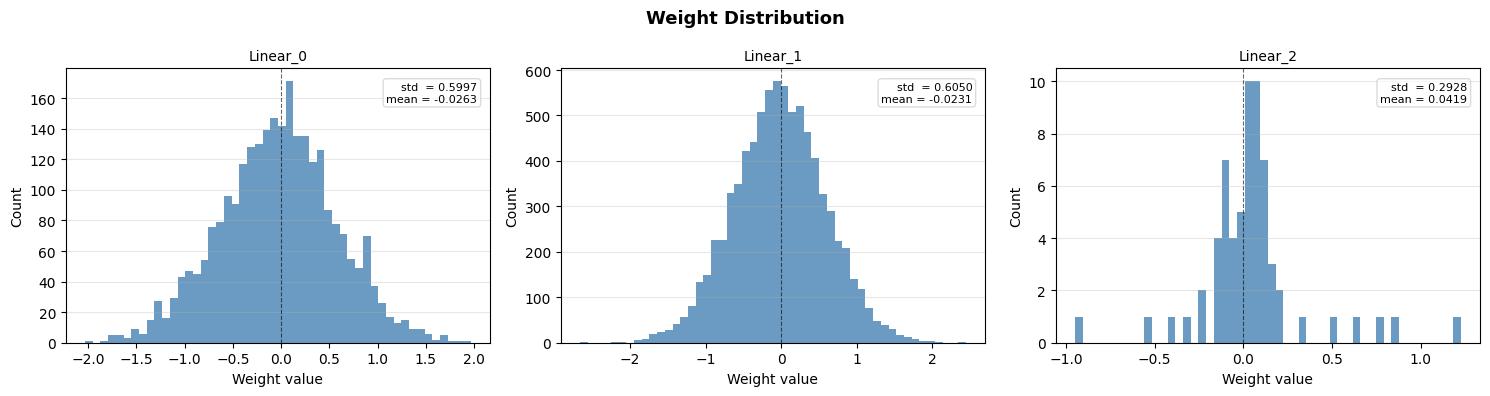

In [94]:
weights = model_normal.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

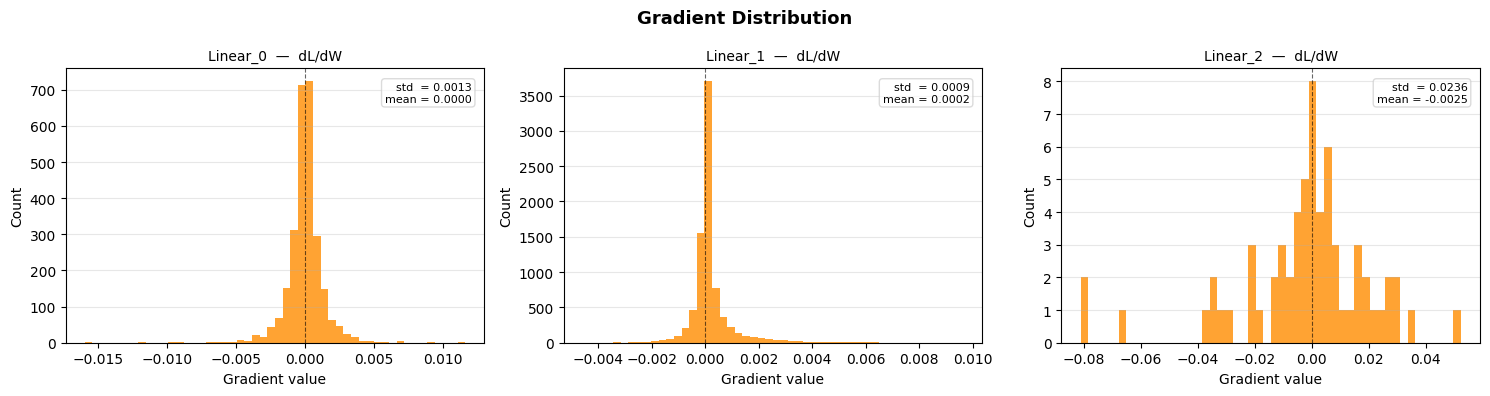

In [95]:
y_pred_viz = model_normal.forward(X_test)
model_normal.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_normal.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [96]:
y_pred  = model_normal.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7250


### Save Model

In [97]:
os.makedirs('../output', exist_ok=True)
model_normal.save('../output/normal_initializer.npz')

[FFNN] Model tersimpan di '../output/normal_initializer.npz' 


## Model 4: FFNN + Xavier Initialization

In [98]:
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

for epoch in range(1, EPOCHS + 1):
    metrics = model_xavier.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6552  |  val_loss: 0.6106  |  val_acc: 0.6675
Epoch   2/500  |  train_loss: 0.5961  |  val_loss: 0.5585  |  val_acc: 0.7212
Epoch   3/500  |  train_loss: 0.5557  |  val_loss: 0.5225  |  val_acc: 0.7462
Epoch   4/500  |  train_loss: 0.5298  |  val_loss: 0.5009  |  val_acc: 0.7731
Epoch   5/500  |  train_loss: 0.5142  |  val_loss: 0.4891  |  val_acc: 0.7725
Epoch   6/500  |  train_loss: 0.5056  |  val_loss: 0.4821  |  val_acc: 0.7725
Epoch   7/500  |  train_loss: 0.5006  |  val_loss: 0.4784  |  val_acc: 0.7738
Epoch   8/500  |  train_loss: 0.4976  |  val_loss: 0.4765  |  val_acc: 0.7731
Epoch   9/500  |  train_loss: 0.4953  |  val_loss: 0.4758  |  val_acc: 0.7694
Epoch  10/500  |  train_loss: 0.4942  |  val_loss: 0.4742  |  val_acc: 0.7706
Epoch  11/500  |  train_loss: 0.4930  |  val_loss: 0.4735  |  val_acc: 0.7706
Epoch  12/500  |  train_loss: 0.4920  |  val_loss: 0.4737  |  val_acc: 0.7650
Epoch  13/500  |  train_loss: 0.4910  |  val_loss: 0.4733  |  va

### Visualisasi

### 1. Plot Traning History

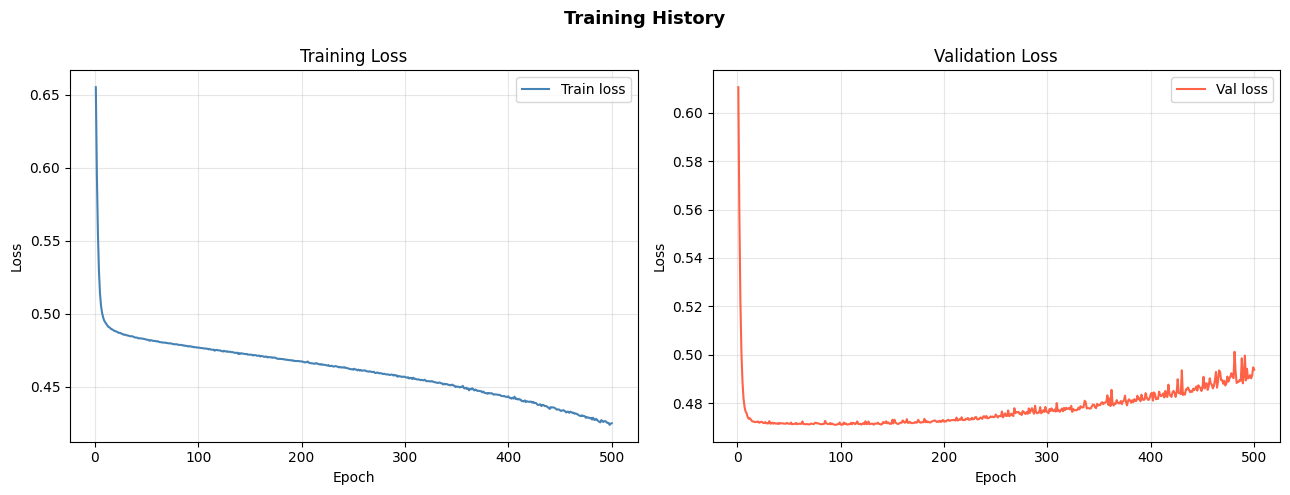

In [99]:
viz = Visualizer()
history = model_xavier.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

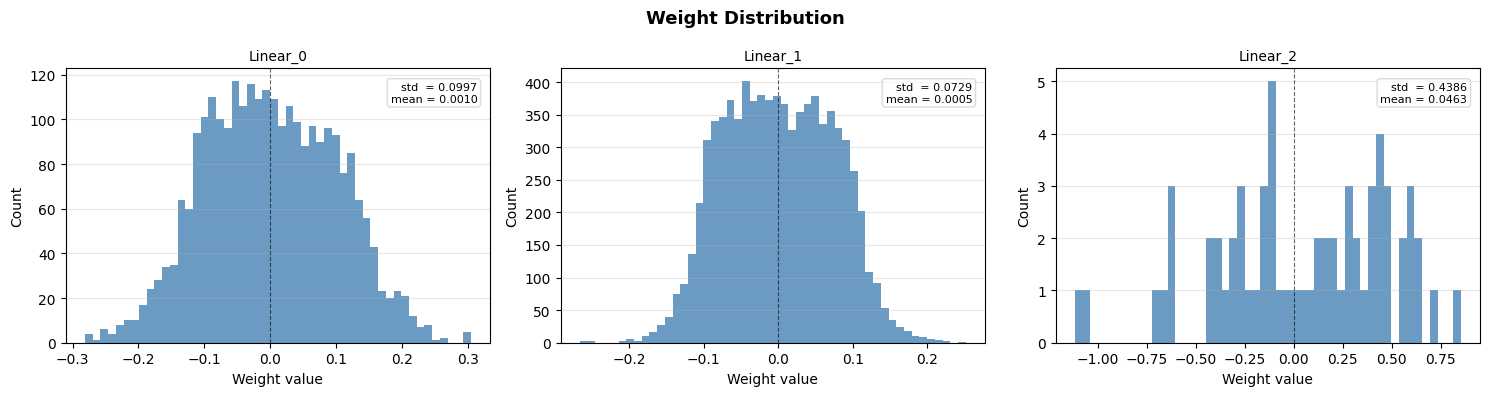

In [100]:
weights = model_xavier.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

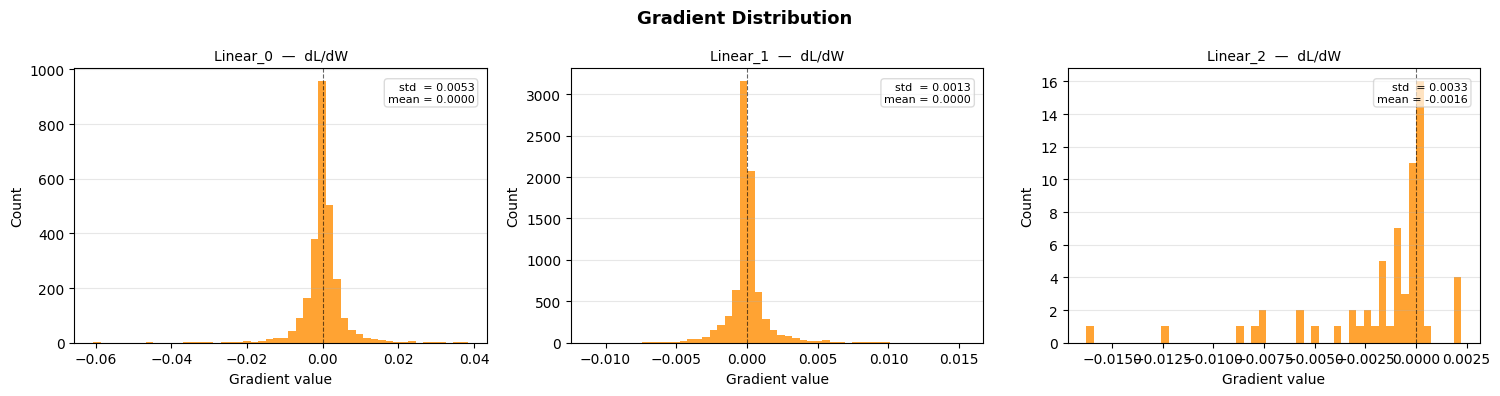

In [101]:
y_pred_viz = model_xavier.forward(X_test)
model_xavier.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_xavier.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [102]:
y_pred  = model_xavier.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7310


### Save Model

In [103]:
os.makedirs('../output', exist_ok=True)
model_xavier.save('../output/xavier_initializer.npz')

[FFNN] Model tersimpan di '../output/xavier_initializer.npz' 


## Model 5: FFNN + He Initialization

In [104]:
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=1e-3)

for epoch in range(1, EPOCHS + 1):
    metrics = model_he.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/500  |  train_loss: 0.6347  |  val_loss: 0.5544  |  val_acc: 0.7331
Epoch   2/500  |  train_loss: 0.5463  |  val_loss: 0.5138  |  val_acc: 0.7594
Epoch   3/500  |  train_loss: 0.5204  |  val_loss: 0.5035  |  val_acc: 0.7556
Epoch   4/500  |  train_loss: 0.5098  |  val_loss: 0.4931  |  val_acc: 0.7675
Epoch   5/500  |  train_loss: 0.5037  |  val_loss: 0.4896  |  val_acc: 0.7656
Epoch   6/500  |  train_loss: 0.5004  |  val_loss: 0.4887  |  val_acc: 0.7612
Epoch   7/500  |  train_loss: 0.4981  |  val_loss: 0.4858  |  val_acc: 0.7644
Epoch   8/500  |  train_loss: 0.4965  |  val_loss: 0.4858  |  val_acc: 0.7619
Epoch   9/500  |  train_loss: 0.4953  |  val_loss: 0.4850  |  val_acc: 0.7656
Epoch  10/500  |  train_loss: 0.4935  |  val_loss: 0.4879  |  val_acc: 0.7612
Epoch  11/500  |  train_loss: 0.4936  |  val_loss: 0.4846  |  val_acc: 0.7600
Epoch  12/500  |  train_loss: 0.4923  |  val_loss: 0.4832  |  val_acc: 0.7638
Epoch  13/500  |  train_loss: 0.4920  |  val_loss: 0.4832  |  va

### 1. Plot Traning History

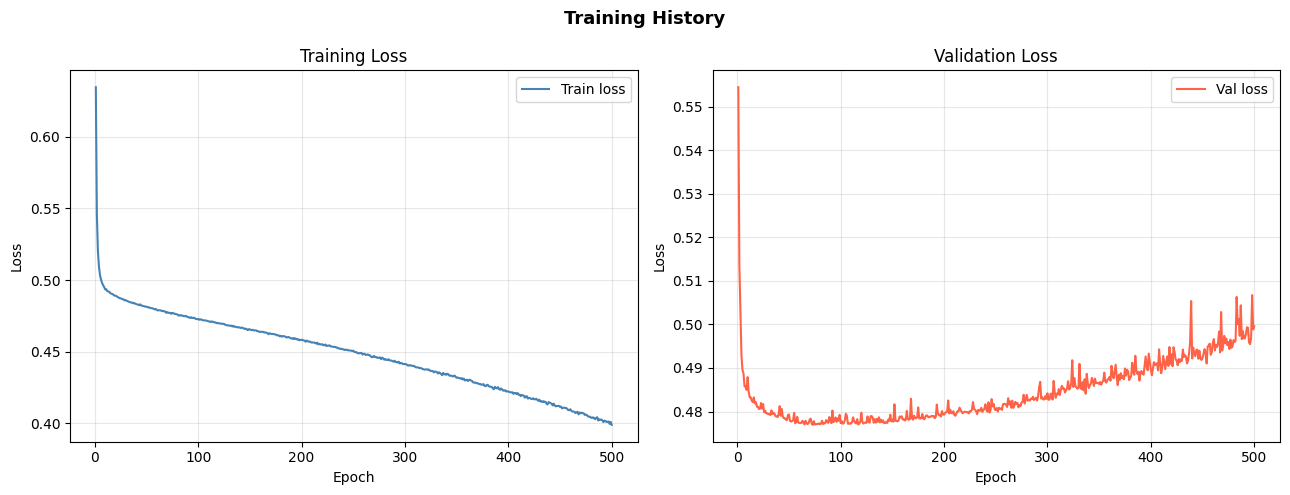

In [105]:
viz = Visualizer()
history = model_he.get_training_history()
viz.plot_loss_curve(history, title='Training History')

### 2. Plot Weight Distribution

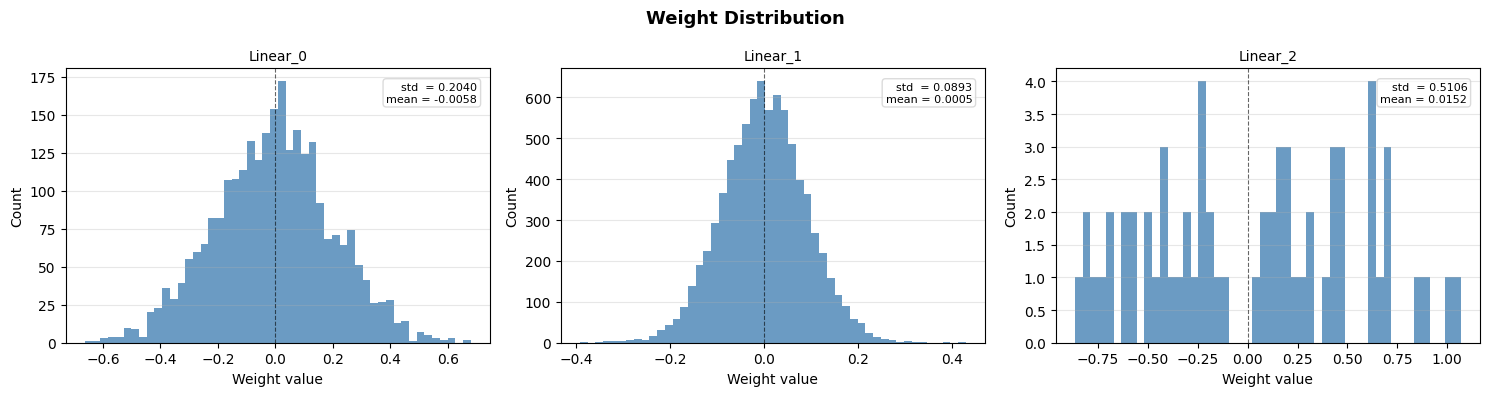

In [106]:
weights = model_he.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution'
)

### 3. Plot Gradient Distribution

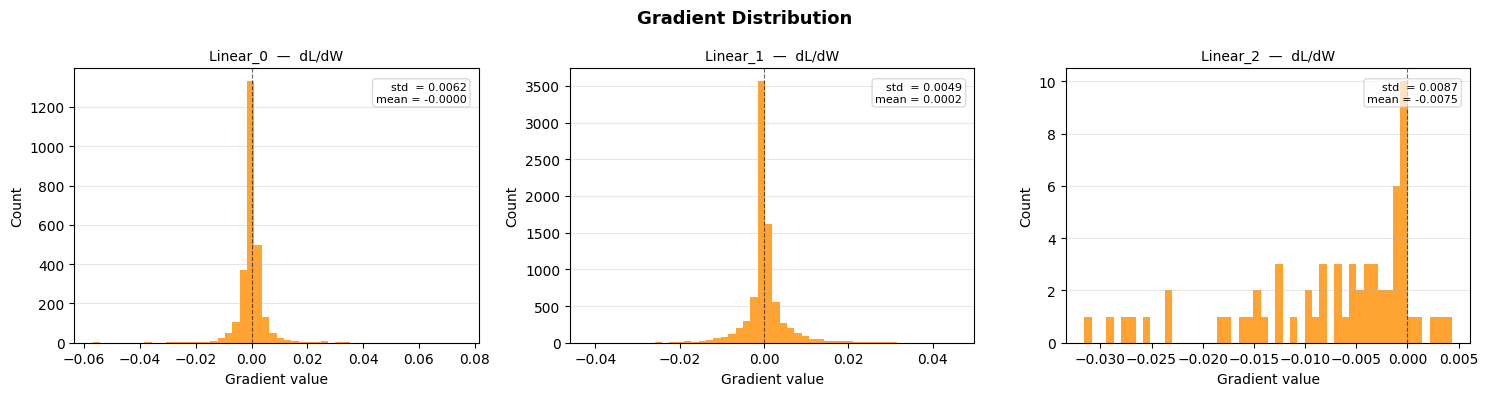

In [107]:
y_pred_viz = model_he.forward(X_test)
model_he.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model_he.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution'
)

### Prediction 

In [108]:
y_pred  = model_he.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7255


### Save Model

In [109]:
os.makedirs('../output', exist_ok=True)
model_he.save('../output/he_initializer.npz')

[FFNN] Model tersimpan di '../output/he_initializer.npz' 
